# Google Meridian MMM Case Study
Candidate: Ulyana Luzhkova
Role: Junior Data Analyst / Analytics Engineer

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../data/MMM_data.xlsx")
df.head()

,TV Manufacturing Brand,DATE,DEMAND,Consumer Price Index (CPI),Consumer Confidence Index(CCI),Producer Price Index (PPI),Unit Price ($),POS/ Supply Data,SALES ($),Advertising Expenses (SMS),Advertising Expenses(Newspaper ads),Advertising Expenses(Radio),Advertising Expenses(TV),Advertising Expenses(Internet),GRP (NewPaper ads),GRP(SMS),GRP(Radio,GRP(Internet),GRP(TV)
0,TV Manufacturing & Supplier Unit,2010-01-01,4384,104.9,96.3,106.7,361.62,4240,1533268.80,77.4819,14.104193,112.3370,1479.4565,722.571,95.333,11.8398,91.0000,276.3636,756.5909
1,TV Manufacturing & Supplier Unit,2010-01-02,4366,104.9,96.3,106.7,361.62,4266,1542670.92,73.4783,13.298758,105.7133,1369.8913,717.857,114.957,27.8039,111.9091,291.3182,860.1364
2,TV Manufacturing & Supplier Unit,2010-01-03,4006,104.9,96.3,106.7,361.62,4206,1520973.72,80.6093,13.200691,108.7702,1428.0645,653.333,113.090,0.0000,94.6364,282.7273,751.9545
3,TV Manufacturing & Supplier Unit,2010-01-04,4076,104.9,96.3,106.7,361.62,4176,1510125.12,65.9319,12.721429,93.3065,1309.3548,622.095,72.442,0.0000,98.5909,306.3182,749.4545
4,TV Manufacturing & Supplier Unit,2010-01-05,4834,104.9,96.3,106.7,361.62,5234,1892719.08,77.4819,14.104193,112.3370,1479.4565,722.571,95.333,11.8398,91.0000,276.3636,756.5909


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2613 entries, 0 to 2612
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   TV Manufacturing Brand               2613 non-null   object        
 1   DATE                                 2613 non-null   datetime64[ns]
 2   DEMAND                               2613 non-null   int64         
 3   Consumer Price Index (CPI)           2613 non-null   float64       
 4   Consumer Confidence Index(CCI)       2613 non-null   float64       
 5   Producer Price Index (PPI)           2613 non-null   float64       
 6   Unit Price ($)                       2613 non-null   float64       
 7   POS/ Supply Data                     2613 non-null   int64         
 8   SALES ($)                            2613 non-null   float64       
 9   Advertising Expenses (SMS)           2613 non-null   float64       
 10  Advertising 

In [8]:
df.shape

(2613, 19)

In [21]:
df = pd.read_excel("../data/MMM_data.xlsx")
print(df.columns.tolist())


['TV Manufacturing Brand', 'DATE', 'DEMAND ', 'Consumer Price Index (CPI)', 'Consumer Confidence Index(CCI)', 'Producer Price Index (PPI)', 'Unit Price ($)', 'POS/ Supply Data', 'SALES ($)', 'Advertising Expenses (SMS)', 'Advertising Expenses(Newspaper ads)', 'Advertising Expenses(Radio)', 'Advertising Expenses(TV)', 'Advertising Expenses(Internet)', 'GRP (NewPaper ads)', 'GRP(SMS)', 'GRP(Radio', 'GRP(Internet)', 'GRP(TV)']


# 1. Weekly Resampling: Агрегируйте ежедневные данные в недельные (с началом в воскресенье). Убедитесь, что Sales и Spend суммируются, а индексы (CPI, CCI) — усредняются.

In [38]:
df['WEEK'] = df ['DATE'].dt.to_period('W-SAT')

weekly = df.groupby('WEEK').agg({
    # показатели
    'DEMAND ': 'sum',
    'SALES ($)': 'sum',

    # затраты на рекламу
    'Advertising Expenses (SMS)': 'sum',
    'Advertising Expenses(Newspaper ads)': 'sum',
    'Advertising Expenses(Radio)': 'sum',
    'Advertising Expenses(TV)': 'sum',
    'Advertising Expenses(Internet)': 'sum',

    #GPR
    'GRP (NewPaper ads)': 'sum',
    'GRP(SMS)': 'sum',
    'GRP(Radio': 'sum',
    'GRP(Internet)': 'sum',
    'GRP(TV)': 'sum',

    #индексы + цена за 1
    'Consumer Price Index (CPI)': 'mean',
    'Consumer Confidence Index(CCI)': 'mean',
    'Producer Price Index (PPI)': 'mean',
    'Unit Price ($)': 'mean'
}).reset_index()

print(weekly.head())
print(f"Количество недель: {len(weekly)}")


                    WEEK  DEMAND     SALES ($)  Advertising Expenses (SMS)  \
0  2009-12-27/2010-01-02     8750   3075939.72                    150.9602   
1  2010-01-03/2010-01-09    30309  11256868.98                    533.7709   
2  2010-01-10/2010-01-16    36362  13402360.44                    518.1557   
3  2010-01-17/2010-01-23    48450  18297972.00                    484.6265   
4  2010-01-24/2010-01-30    74249  26132469.30                    536.7159   

   Advertising Expenses(Newspaper ads)  Advertising Expenses(Radio)  \
0                            27.402951                     218.0503   
1                            93.039505                     739.8396   
2                            91.979720                     706.1484   
3                            93.097681                     684.7018   
4                            94.415522                     728.2976   

   Advertising Expenses(TV)  Advertising Expenses(Internet)  \
0                 2849.3478              

# 3. Data Quality Check: Выявите пропуски или аномалии в данных (например, периоды отсутствия стока POS/ Supply Data).


1. Пропущенные значения (weekly):
WEEK                                   0
DEMAND                                 0
SALES ($)                              0
Advertising Expenses (SMS)             0
Advertising Expenses(Newspaper ads)    0
Advertising Expenses(Radio)            0
Advertising Expenses(TV)               0
Advertising Expenses(Internet)         0
GRP (NewPaper ads)                     0
GRP(SMS)                               0
GRP(Radio                              0
GRP(Internet)                          0
GRP(TV)                                0
Consumer Price Index (CPI)             0
Consumer Confidence Index(CCI)         0
Producer Price Index (PPI)             0
Unit Price ($)                         0
dtype: int64

Пропущенные значения (daily):
TV Manufacturing Brand                 0
DATE                                   0
DEMAND                                 0
Consumer Price Index (CPI)             0
Consumer Confidence Index(CCI)         0
Producer Price Index

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\datetimelike.py:1306: RuntimeWarning: overflow encountered in scalar multiply
  new_data = np.array([self.freq.base * x for x in new_i8_data])


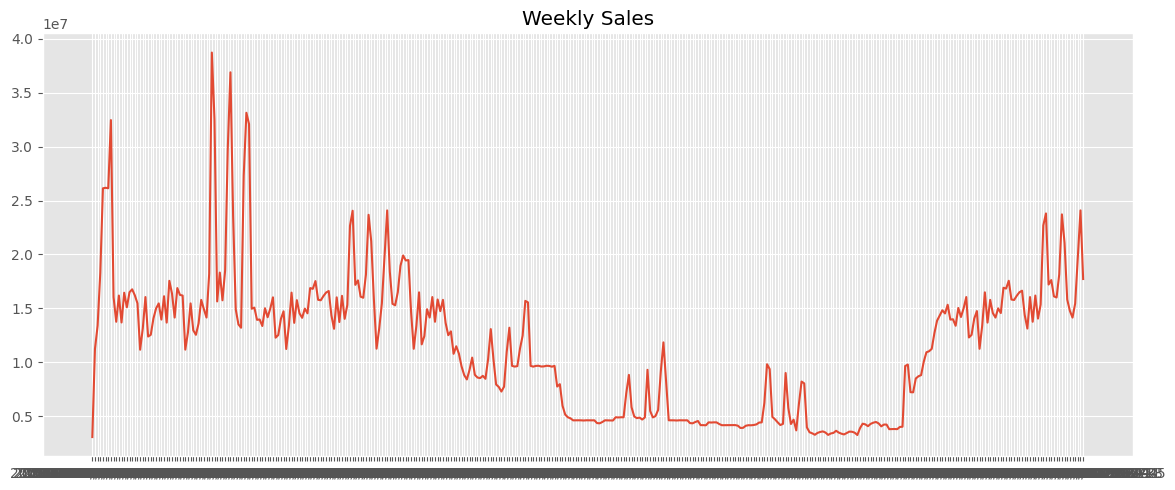

In [40]:
import numpy as np
import matplotlib.pyplot as plt

print("1. Пропущенные значения (weekly):")
print(weekly.isnull().sum())

print("\nПропущенные значения (daily):")
print(df.isnull().sum())

print("\n2. Непрерывность дней (daily):")
daily_diff = df['DATE'].sort_values().diff().value_counts()
print(daily_diff)

print("\n3. Непрерывность недель (weekly):")
weekly_diff = weekly['WEEK'].sort_values().diff().value_counts()
print(weekly_diff)

zero_sales_weekly = (weekly['SALES ($)'] == 0).sum()
zero_sales_daily = (df['SALES ($)'] == 0).sum()
print("\n4. Нулевые продажи:")
print("Недели с нулевыми продажами:", zero_sales_weekly)
print("Дни с нулевыми продажами:", zero_sales_daily)

zero_stock = (df['POS/ Supply Data'] == 0).sum()
print("\n5. Периоды отсутствия стока:", zero_stock)

negative_values = (weekly.select_dtypes(include=[np.number]) < 0).sum()
print("\n6. Отрицательные значения в недельных данных:")
print(negative_values)
print("\nОтрицательные значения в дневных данных:")
print((df.select_dtypes(include=[np.number]) < 0).sum())

print("\n7. Статистика продаж (weekly):")
print(weekly['SALES ($)'].describe())

# график продаж
plt.figure(figsize=(12,5))
plt.plot(weekly['WEEK'].astype(str), weekly['SALES ($)'])
plt.title("Weekly Sales")
plt.tight_layout()
plt.show()

### Data Quality Check: Результаты проверки

#### 1. Пропущенные значения
- **Weekly data**: 0 пропусков во всех колонках 
- **Daily data**: 0 пропусков во всех колонках

#### 2. Непрерывность временного ряда
- **Daily**: все дни идут подряд: 2612 интервалов по 1 дню на 2613 дней 
- **Weekly**: все недели идут подряд: 373 интервала по 1 неделе на 374 недели

#### 3. Нулевые продажи
- **Weekly**: 0 недель с нулевыми продажами 
- **Daily**: 0 дней с нулевыми продажами 

#### 4. Отсутствие стока (POS/Supply Data)
- **Дней с нулевым стоком**: 0 

#### 5. Отрицательные значения
- **Weekly data**: 0 отрицательных значений во всех колонках 

#### 6. Статистика недельных продаж
- **Количество недель**: 374
- **Средние продажи**: 11 468 600 $

- **Минимальные**: 3 075 940 $
  
- **Максимальные**: 38 714 680 $
  
- **Медиана**: 12 350 410 $
  
- **Вывод**: разброс большой, медиана близка к среднему, max в 3 раза выше среднего (высокие пики)

#### 7. Визуальный анализ
На графике недельных продаж наблюдается:
- Сезонность (регулярные пики и спады)
- Растущий тренд к концу периода

### Итоговое заключение
- Нет пропусков
- Непрерывный временной ряд
- Нет периодов отсутствия товара
- Нет отрицательных значений
- Все недели имеют ненулевые затраты и продажи

Качество данных идеальное — дополнительная очистка не требуется.